In [8]:
!rm -rf /content/drive

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Setup paths and unzip repo**

# **Install packages and check GPU**

In [10]:
!pip install -q cooler lpips pytorch-msssim tensorboard scikit-image scikit-learn opencv-python

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.3/109.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 76.6 MB/s eta 0:00:00


In [11]:
import torch
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


# **Preprocess example data once**

In [12]:
%cd /content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main/scripts

!python3 makedata.py \
  --ficool_dir ./../example_data/ \
  --sub_mat_n 64 \
  --output_folder ./../example_data/processed/ \
  --timepoints PN5 early_2cell late_2cell 8cell ICM mESC_500 \
  --chromosomes chr19

/content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main/scripts
chr19 (6, 490, 64, 64) (490, 6, 64, 64) (6, 490, 2) (490, 6, 2)
Chromosome saved.
mat_chr2.shape:  (1, 1534, 1534)
mat_chr2.shape:  (1, 1534, 1534)
mat_chr2.shape:  (1, 1534, 1534)
mat_chr2.shape:  (1, 1534, 1534)
mat_chr2.shape:  (1, 1534, 1534)
mat_chr2.shape:  (1, 1534, 1534)
ground_truth.shape:  (6, 1534, 1534)
Ground truth saved.


# **copy input_patches/data_chr19_64.npy into train_patches/ before training**

In [13]:
import os

ROOT = "/content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main"
%cd {ROOT}

os.makedirs(f"{ROOT}/example_data/processed/train_patches", exist_ok=True)

src = f"{ROOT}/example_data/processed/input_patches/data_chr19_64.npy"
dst = f"{ROOT}/example_data/processed/train_patches/data_chr19_64.npy"

# Ensure shutil is imported
import shutil
shutil.copy2(src, dst)

print("Copied training patch file:")
print(dst)

/content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main
Copied training patch file:
/content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main/example_data/processed/train_patches/data_chr19_64.npy


# **Sanity-check the processed files**

In [14]:
import numpy as np

gt = np.load(f"{ROOT}/example_data/processed/data_gt_chr19_64.npy")
patches = np.load(f"{ROOT}/example_data/processed/input_patches/data_chr19_64.npy")
idx = np.load(f"{ROOT}/example_data/processed/input_patches/data_index_chr19_64.npy")

print("GT shape:", gt.shape)
print("patches shape:", patches.shape)
print("index shape:", idx.shape)

GT shape: (6, 1534, 1534)
patches shape: (490, 6, 64, 64)
index shape: (490, 6, 2)


# **Patch train.py into train_seeded.py**

In [15]:
from pathlib import Path

train_path = Path(f"{ROOT}/scripts/train.py")
seeded_path = Path(f"{ROOT}/scripts/train_seeded.py")

text = train_path.read_text()

# 1) add parser args
text = text.replace(
    "parser.add_argument('--batch_max', action='store_true')\nparser.add_argument('--no_batch_max', dest='batch_max', action='store_false')",
    "parser.add_argument('--batch_max', action='store_true')\n"
    "parser.add_argument('--no_batch_max', dest='batch_max', action='store_false')\n"
    "parser.add_argument('--seed', default=1234, type=int)\n"
    "parser.add_argument('--output_tag', default='', type=str)"
)

# 2) replace hardcoded seed
text = text.replace(
    "seed = 1234\nrandom.seed(seed)\nnp.random.seed(seed)\ntorch.manual_seed(seed)\ntorch.cuda.manual_seed_all(seed)\ntorch.backends.cudnn.benchmark = True",
    "seed = args.seed\n"
    "random.seed(seed)\n"
    "np.random.seed(seed)\n"
    "torch.manual_seed(seed)\n"
    "torch.cuda.manual_seed_all(seed)\n"
    "torch.backends.cudnn.benchmark = False\n"
    "torch.backends.cudnn.deterministic = True"
)

# 3) add output_tag suffix
text = text.replace(
    "current_time = get_timestamp()\ncode_test = args.code_test",
    "current_time = get_timestamp()\n"
    "tag_suffix = ('_' + args.output_tag) if args.output_tag else ''\n"
    "code_test = args.code_test"
)

text = text.replace(
    "output_folder = 'HiCForecast_train_{}_test'.format(current_time)",
    "output_folder = 'HiCForecast_train_{}{}_test'.format(current_time, tag_suffix)"
)

text = text.replace(
    "output_folder = 'HiCForecast_train_{}'.format(current_time)",
    "output_folder = 'HiCForecast_train_{}{}'.format(current_time, tag_suffix)"
)

seeded_path.write_text(text)
print("Wrote:", seeded_path)

Wrote: /content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main/scripts/train_seeded.py


# **Quick check that the patch worked**

In [16]:
!grep -n "seed\|output_tag\|tag_suffix" /content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main/scripts/train_seeded.py | sed -n '1,40p'

78:parser.add_argument('--seed', default=1234, type=int)
79:parser.add_argument('--output_tag', default='', type=str)
89:seed = args.seed
90:random.seed(seed)
91:np.random.seed(seed)
92:torch.manual_seed(seed)
93:torch.cuda.manual_seed_all(seed)
122:tag_suffix = ('_' + args.output_tag) if args.output_tag else ''
125:    output_folder = 'HiCForecast_train_{}{}_test'.format(current_time, tag_suffix)
130:    output_folder = 'HiCForecast_train_{}{}'.format(current_time, tag_suffix)


# **Set ensemble experiment config**

In [17]:
ENSEMBLE_SEEDS = [11, 22, 33]
FT_EPOCHS = 5          # start with 5; increase later if stable
BATCH_SIZE = 8
PATCH_SIZE = 64
MAX_HIC = 300
DEVICE_ID = 0
LOSS_NAME = "single_channel_L1_no_vgg"

PRETRAINED = f"{ROOT}/trained_model/HiCForecast.pkl"
DATA_VAL = f"{ROOT}/example_data/processed/input_patches/data_chr19_64.npy"
DATA_TRAIN_DIR = f"{ROOT}/example_data/processed/train_patches/"
VAL_GT = f"{ROOT}/example_data/processed/data_gt_chr19_64.npy"
VAL_INDEX = f"{ROOT}/example_data/processed/input_patches/data_index_chr19_64.npy"

print("Using pretrained start:", PRETRAINED)

Using pretrained start: /content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main/trained_model/HiCForecast.pkl


# **Train ensemble member 1**

In [18]:
%cd /content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main/scripts

seed = ENSEMBLE_SEEDS[0]
tag = f"seed{seed}"

!torchrun --nproc_per_node=1 --master_port=29501 train_seeded.py \
  --epoch {1 + FT_EPOCHS} \
  --max_HiC {MAX_HIC} \
  --patch_size {PATCH_SIZE} \
  --num_gpu 1 \
  --device_id {DEVICE_ID} \
  --num_workers 1 \
  --batch_size {BATCH_SIZE} \
  --lr_scale 1.0 \
  --block_num 9 \
  --data_val_path {DATA_VAL} \
  --data_train_path {DATA_TRAIN_DIR} \
  --resume_path {PRETRAINED} \
  --resume_epoch 1 \
  --early_stoppage_epochs 5 \
  --early_stoppage_start 400 \
  --loss {LOSS_NAME} \
  --val_gt_path {VAL_GT} \
  --val_file_index_path {VAL_INDEX} \
  --no_cut_off \
  --dynamics \
  --no_max_cut_off \
  --no_batch_max \
  --seed {seed} \
  --output_tag {tag} \
  --no_code_test

/content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main/scripts
2026-04-24 20:45:31.046672: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777063531.067022    6179 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777063531.073749    6179 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777063531.091424    6179 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777063531.091468    6179 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000

# **Find the trained checkpoint for member 1**

In [19]:
import glob, os, re

def latest_run_for_tag(tag):
    runs = sorted(glob.glob(f"{ROOT}/scripts/HiCForecast_train_*_{tag}"))
    if not runs:
        raise FileNotFoundError(f"No runs found for tag={tag}")
    return runs[-1]

def latest_cache_checkpoint(run_dir):
    ckpts = glob.glob(os.path.join(run_dir, "cache", "HiCForecast_*.pkl"))
    if not ckpts:
        raise FileNotFoundError(f"No cache checkpoints found in {run_dir}")
    def epoch_num(p):
        m = re.search(r"HiCForecast_(\d+)\.pkl$", p)
        return int(m.group(1)) if m else -1
    ckpts = sorted(ckpts, key=epoch_num)
    return ckpts[-1]

run_dir = latest_run_for_tag("seed11")
ckpt = latest_cache_checkpoint(run_dir)

print("Run dir:", run_dir)
print("Checkpoint:", ckpt)

Run dir: /content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main/scripts/HiCForecast_train_20260424_154555_seed11
Checkpoint: /content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main/scripts/HiCForecast_train_20260424_154555_seed11/cache/HiCForecast_5.pkl


# **Run inference for member 1**

In [20]:
member_out_dir = f"{ROOT}/ensemble_outputs"
os.makedirs(member_out_dir, exist_ok=True)

member_pred_path = f"{member_out_dir}/pred_seed11"

!python3 inference.py \
  --max_HiC {MAX_HIC} \
  --patch_size {PATCH_SIZE} \
  --cut_off \
  --model_path {ckpt} \
  --data_path {DATA_VAL} \
  --output_path {member_pred_path} \
  --file_index_path {VAL_INDEX} \
  --no_batch_max \
  --gt_path {VAL_GT}

2026-04-24 20:49:26.870449: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777063766.904920    7270 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777063766.916488    7270 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777063766.943969    7270 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777063766.944005    7270 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777063766.944013    7270 computation_placer.cc:177] computation placer alr

# **Check member 1 output**

In [21]:
pred_11 = np.load(f"{member_pred_path}.npy")
print("pred_seed11 shape:", pred_11.shape)

pred_seed11 shape: (3, 1534, 1534)


# **Train the remaining ensemble members**

In [22]:
%cd /content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main/scripts

for i, seed in enumerate(ENSEMBLE_SEEDS):
    tag = f"seed{seed}"
    port = 29501 + i

    print(f"\n=== Training member: {tag} ===")
    !torchrun --nproc_per_node=1 --master_port={port} train_seeded.py \
      --epoch {1 + FT_EPOCHS} \
      --max_HiC {MAX_HIC} \
      --patch_size {PATCH_SIZE} \
      --num_gpu 1 \
      --device_id {DEVICE_ID} \
      --num_workers 1 \
      --batch_size {BATCH_SIZE} \
      --lr_scale 1.0 \
      --block_num 9 \
      --data_val_path {DATA_VAL} \
      --data_train_path {DATA_TRAIN_DIR} \
      --resume_path {PRETRAINED} \
      --resume_epoch 1 \
      --early_stoppage_epochs 5 \
      --early_stoppage_start 400 \
      --loss {LOSS_NAME} \
      --val_gt_path {VAL_GT} \
      --val_file_index_path {VAL_INDEX} \
      --no_cut_off \
      --dynamics \
      --no_max_cut_off \
      --no_batch_max \
      --seed {seed} \
      --output_tag {tag} \
      --no_code_test

/content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main/scripts

=== Training member: seed11 ===
2026-04-24 20:50:02.857817: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777063802.878496    7450 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777063802.885543    7450 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777063802.902627    7450 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777063802.902673    7450 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the 

# **Run inference for all ensemble members**

In [23]:
%cd /content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main/scripts

member_paths = []

for seed in ENSEMBLE_SEEDS:
    tag = f"seed{seed}"
    run_dir = latest_run_for_tag(tag)
    ckpt = latest_cache_checkpoint(run_dir)

    out_prefix = f"{ROOT}/ensemble_outputs/pred_{tag}"
    print(f"\n=== Inference for {tag} ===")
    print("checkpoint:", ckpt)

    !python3 inference.py \
      --max_HiC {MAX_HIC} \
      --patch_size {PATCH_SIZE} \
      --cut_off \
      --model_path {ckpt} \
      --data_path {DATA_VAL} \
      --output_path {out_prefix} \
      --file_index_path {VAL_INDEX} \
      --no_batch_max \
      --gt_path {VAL_GT}

    member_paths.append(f"{out_prefix}.npy")

print("\nSaved prediction files:")
for p in member_paths:
    print(p)

/content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main/scripts

=== Inference for seed11 ===
checkpoint: /content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main/scripts/HiCForecast_train_20260424_155008_seed11/cache/HiCForecast_5.pkl
2026-04-24 20:59:26.129861: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777064366.150678   10089 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777064366.157880   10089 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777064366.175599   10089 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more th

# **Build the true ensemble: mean and std**

In [24]:
member_preds = [np.load(p) for p in member_paths]
member_preds = np.stack(member_preds, axis=0)   # (M, 3, N, N)

ensemble_mean = member_preds.mean(axis=0)       # (3, N, N)
ensemble_std = member_preds.std(axis=0)         # (3, N, N)

np.save(f"{ROOT}/ensemble_outputs/pred_ensemble_mean.npy", ensemble_mean)
np.save(f"{ROOT}/ensemble_outputs/pred_ensemble_std.npy", ensemble_std)

print("member_preds shape:", member_preds.shape)
print("ensemble_mean shape:", ensemble_mean.shape)
print("ensemble_std shape:", ensemble_std.shape)

member_preds shape: (3, 3, 1534, 1534)
ensemble_mean shape: (3, 1534, 1534)
ensemble_std shape: (3, 1534, 1534)


# **Visualize mean and uncertainty maps**

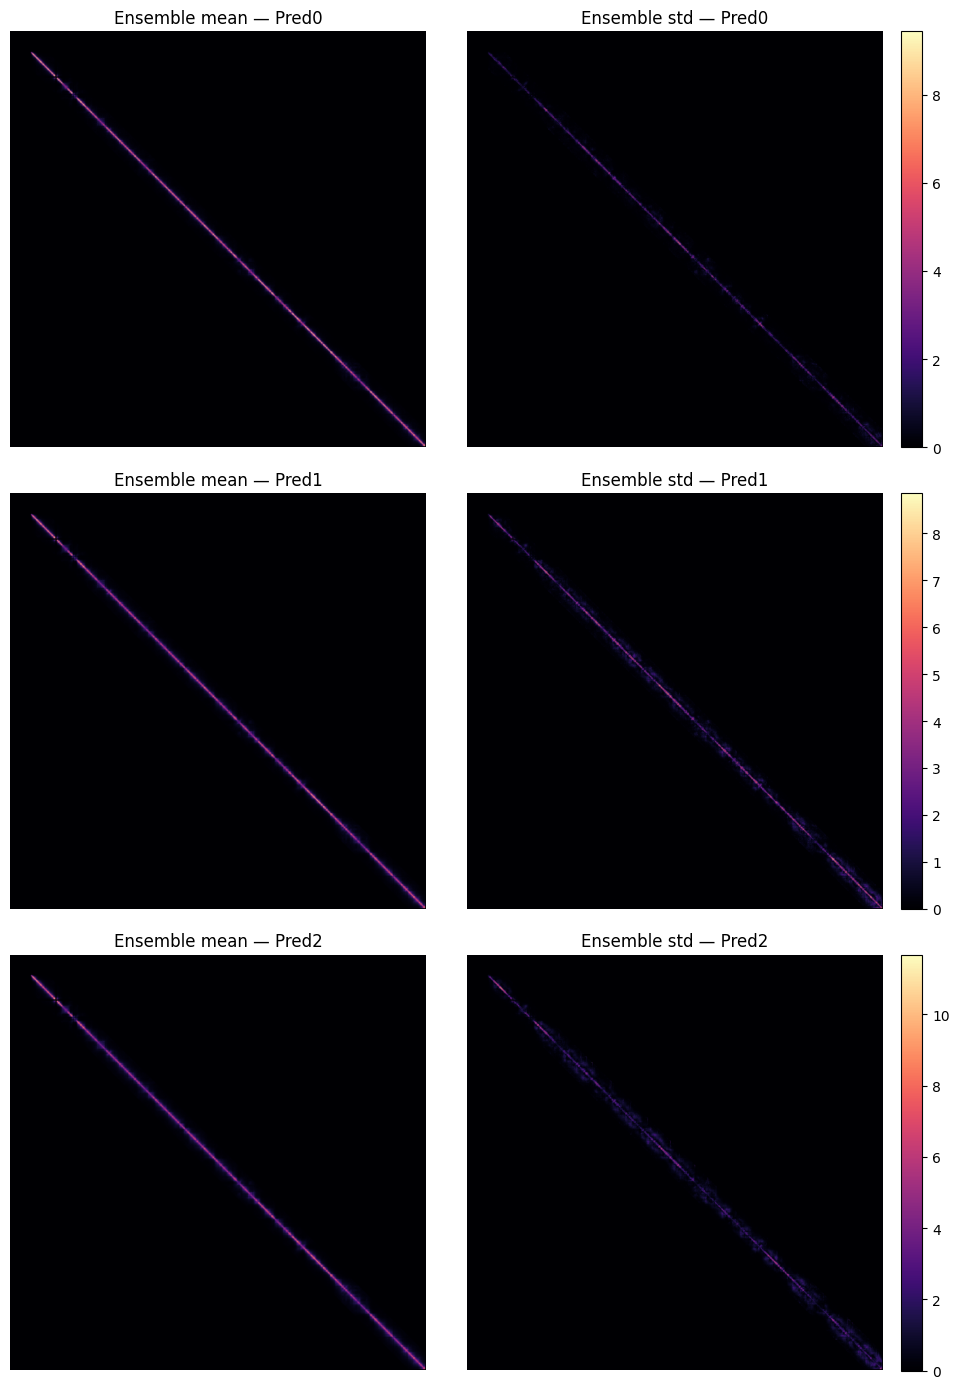

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(10, 14))
for i in range(3):
    axes[i, 0].imshow(ensemble_mean[i], cmap="magma")
    axes[i, 0].set_title(f"Ensemble mean — Pred{i}")
    axes[i, 0].axis("off")

    im = axes[i, 1].imshow(ensemble_std[i], cmap="magma")
    axes[i, 1].set_title(f"Ensemble std — Pred{i}")
    axes[i, 1].axis("off")
    plt.colorbar(im, ax=axes[i, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# **Compare uncertainty with actual error**

In [26]:
gt = np.load(VAL_GT)
gt_match = [2, 5, 5]

for i, gt_idx in enumerate(gt_match):
    err = np.abs(ensemble_mean[i] - gt[gt_idx])
    unc = ensemble_std[i]

    corr = np.corrcoef(err.ravel(), unc.ravel())[0, 1]
    print(f"Pred{i} vs GT{gt_idx} | corr(error, uncertainty) = {corr:.4f}")

Pred0 vs GT2 | corr(error, uncertainty) = 0.6331
Pred1 vs GT5 | corr(error, uncertainty) = 0.5852
Pred2 vs GT5 | corr(error, uncertainty) = 0.6074


# **Uncertainty-bin analysis**

In [27]:
def bin_error_by_uncertainty(unc, err, quantiles=(0.0, 0.5, 0.8, 0.95, 1.0)):
    qs = np.quantile(unc, quantiles)
    rows = []
    for a, b in zip(qs[:-1], qs[1:]):
        if b == qs[-1]:
            mask = (unc >= a) & (unc <= b)
        else:
            mask = (unc >= a) & (unc < b)
        mean_unc = float(unc[mask].mean()) if mask.any() else np.nan
        mean_err = float(err[mask].mean()) if mask.any() else np.nan
        frac = float(mask.mean())
        rows.append((a, b, frac, mean_unc, mean_err))
    return rows

for i, gt_idx in enumerate(gt_match):
    err = np.abs(ensemble_mean[i] - gt[gt_idx])
    unc = ensemble_std[i]
    rows = bin_error_by_uncertainty(unc, err)

    print(f"\nPred{i} vs GT{gt_idx}")
    print("unc_low | unc_high | frac_pixels | mean_unc | mean_abs_err")
    for r in rows:
        print(f"{r[0]:.6f} | {r[1]:.6f} | {r[2]:.3f} | {r[3]:.6f} | {r[4]:.6f}")


Pred0 vs GT2
unc_low | unc_high | frac_pixels | mean_unc | mean_abs_err
0.000000 | 0.000000 | 0.000 | nan | nan
0.000000 | 0.000000 | 0.000 | nan | nan
0.000000 | 0.089170 | 0.950 | 0.001317 | 0.629921
0.089170 | 9.439572 | 0.050 | 0.461068 | 4.950339

Pred1 vs GT5
unc_low | unc_high | frac_pixels | mean_unc | mean_abs_err
0.000000 | 0.000000 | 0.000 | nan | nan
0.000000 | 0.000000 | 0.000 | nan | nan
0.000000 | 0.148941 | 0.950 | 0.002074 | 0.654995
0.148941 | 8.857720 | 0.050 | 0.742158 | 9.273957

Pred2 vs GT5
unc_low | unc_high | frac_pixels | mean_unc | mean_abs_err
0.000000 | 0.000000 | 0.000 | nan | nan
0.000000 | 0.000000 | 0.000 | nan | nan
0.000000 | 0.201224 | 0.950 | 0.002498 | 0.654122
0.201224 | 11.676252 | 0.050 | 0.857427 | 9.477770


# **Plot mean / std / error side by side**

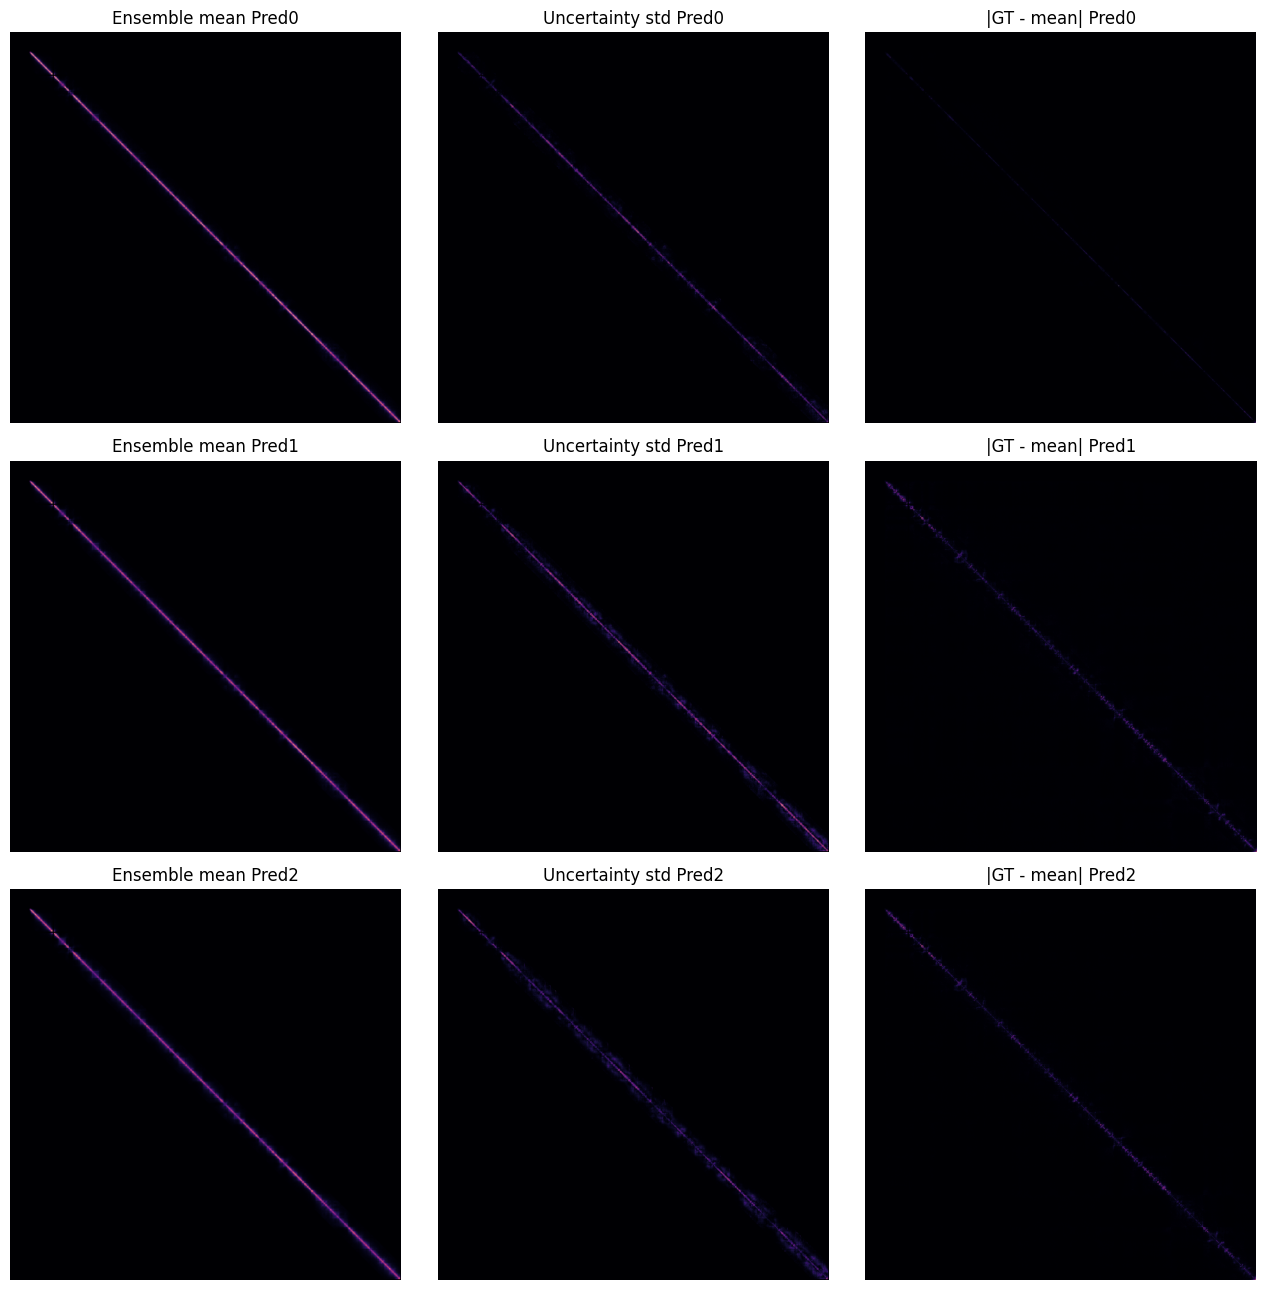

In [28]:
fig, axes = plt.subplots(3, 3, figsize=(13, 13))

for i, gt_idx in enumerate(gt_match):
    g = gt[gt_idx]
    m = ensemble_mean[i]
    s = ensemble_std[i]
    e = np.abs(g - m)

    axes[i, 0].imshow(m, cmap="magma")
    axes[i, 0].set_title(f"Ensemble mean Pred{i}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(s, cmap="magma")
    axes[i, 1].set_title(f"Uncertainty std Pred{i}")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(e, cmap="magma")
    axes[i, 2].set_title(f"|GT - mean| Pred{i}")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

# **Save everything to Drive**

In [29]:
SAVE_DIR = "/content/drive/MyDrive/HicForecast_Project_experiment_1B"
os.makedirs(SAVE_DIR, exist_ok=True)

for p in member_paths:
    shutil.copy2(p, SAVE_DIR)

shutil.copy2(f"{ROOT}/ensemble_outputs/pred_ensemble_mean.npy", SAVE_DIR)
shutil.copy2(f"{ROOT}/ensemble_outputs/pred_ensemble_std.npy", SAVE_DIR)
shutil.copy2(VAL_GT, SAVE_DIR)

print("Saved outputs to:", SAVE_DIR)

Saved outputs to: /content/drive/MyDrive/HicForecast_Project_experiment_1B


# **Load saved ensemble mean and GT**

In [30]:
import numpy as np
import pandas as pd
ROOT = "/content/drive/MyDrive/HicForecast_Project_experiment_1B/HiCForecast-main"
ENSEMBLE_MEAN_PATH = f"{ROOT}/ensemble_outputs/pred_ensemble_mean.npy"
GT_PATH = f"{ROOT}/example_data/processed/data_gt_chr19_64.npy"

ensemble_mean = np.load(ENSEMBLE_MEAN_PATH)
gt = np.load(GT_PATH)

print("ensemble_mean shape:", ensemble_mean.shape)
print("gt shape:", gt.shape)

ensemble_mean shape: (3, 1534, 1534)
gt shape: (6, 1534, 1534)


# **Fixed GT matching**

In [31]:
gt_match = [2, 5, 5]   # Pred0->GT2, Pred1->GT5, Pred2->GT5
print("GT matching:", gt_match)

GT matching: [2, 5, 5]


# **Define the metrics**

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

def compute_pcc(a, b):
    a = a.astype(np.float64).ravel()
    b = b.astype(np.float64).ravel()
    return np.corrcoef(a, b)[0, 1]

def compute_ssim(a, b):
    a = a.astype(np.float64)
    b = b.astype(np.float64)
    data_range = max(a.max(), b.max()) - min(a.min(), b.min())
    if data_range == 0:
        data_range = 1.0
    return ssim(a, b, data_range=data_range)

def compute_psnr(a, b):
    a = a.astype(np.float64)
    b = b.astype(np.float64)
    data_range = max(a.max(), b.max()) - min(a.min(), b.min())
    if data_range == 0:
        data_range = 1.0
    return psnr(a, b, data_range=data_range)

def compute_mae(a, b):
    return mean_absolute_error(a.ravel(), b.ravel())

def compute_mse(a, b):
    return mean_squared_error(a.ravel(), b.ravel())

# **Evaluate ensemble mean**

In [33]:
rows = []

for pred_idx, gt_idx in enumerate(gt_match):
    pred_map = ensemble_mean[pred_idx]
    gt_map = gt[gt_idx]

    rows.append({
        "Pred idx": pred_idx,
        "GT idx": gt_idx,
        "PCC": compute_pcc(gt_map, pred_map),
        "SSIM": compute_ssim(gt_map, pred_map),
        "PSNR": compute_psnr(gt_map, pred_map),
        "MAE": compute_mae(gt_map, pred_map),
        "MSE": compute_mse(gt_map, pred_map),
    })

ensemble_df = pd.DataFrame(rows)
ensemble_df

,Pred idx,GT idx,PCC,SSIM,PSNR,MAE,MSE
0,0,2,0.978473,0.988568,48.860872,0.845942,9.215883
1,1,5,0.943878,0.961117,40.984857,1.085944,16.213149
2,2,5,0.945264,0.960922,40.537026,1.095306,17.974236


# **Show average over 3 horizons**

In [34]:
print("Ensemble mean averages across 3 horizons")
print("PCC :", ensemble_df["PCC"].mean())
print("SSIM:", ensemble_df["SSIM"].mean())
print("PSNR:", ensemble_df["PSNR"].mean())
print("MAE :", ensemble_df["MAE"].mean())
print("MSE :", ensemble_df["MSE"].mean())

Ensemble mean averages across 3 horizons
PCC : 0.9558717396891921
SSIM: 0.970202473068139
PSNR: 43.4609185407119
MAE : 1.0090640831825677
MSE : 14.467756205868186


# **Put my baseline values**

In [35]:
baseline_df = pd.DataFrame([
    {"Pred idx": 0, "GT idx": 2, "PCC": 0.9695, "SSIM": 0.9877, "PSNR": 47.56, "MAE": 0.9199, "MSE": 12.44},
    {"Pred idx": 1, "GT idx": 5, "PCC": 0.9422, "SSIM": 0.9609, "PSNR": 40.44, "MAE": 1.1051, "MSE": 18.39},
    {"Pred idx": 2, "GT idx": 5, "PCC": 0.9431, "SSIM": 0.9604, "PSNR": 40.76, "MAE": 1.1048, "MSE": 17.08},
])

baseline_df

,Pred idx,GT idx,PCC,SSIM,PSNR,MAE,MSE
0,0,2,0.9695,0.9877,47.56,0.9199,12.44
1,1,5,0.9422,0.9609,40.44,1.1051,18.39
2,2,5,0.9431,0.9604,40.76,1.1048,17.08


# **Compare ensemble mean vs baseline**

In [36]:
compare_df = baseline_df.copy()
compare_df = compare_df.rename(columns={
    "PCC": "Baseline PCC",
    "SSIM": "Baseline SSIM",
    "PSNR": "Baseline PSNR",
    "MAE": "Baseline MAE",
    "MSE": "Baseline MSE",
})

compare_df["Ensemble PCC"] = ensemble_df["PCC"]
compare_df["Ensemble SSIM"] = ensemble_df["SSIM"]
compare_df["Ensemble PSNR"] = ensemble_df["PSNR"]
compare_df["Ensemble MAE"] = ensemble_df["MAE"]
compare_df["Ensemble MSE"] = ensemble_df["MSE"]

compare_df["ΔPCC"] = compare_df["Ensemble PCC"] - compare_df["Baseline PCC"]
compare_df["ΔSSIM"] = compare_df["Ensemble SSIM"] - compare_df["Baseline SSIM"]
compare_df["ΔPSNR"] = compare_df["Ensemble PSNR"] - compare_df["Baseline PSNR"]
compare_df["ΔMAE"] = compare_df["Ensemble MAE"] - compare_df["Baseline MAE"]
compare_df["ΔMSE"] = compare_df["Ensemble MSE"] - compare_df["Baseline MSE"]

compare_df.round(4)

,Pred idx,GT idx,Baseline PCC,Baseline SSIM,Baseline PSNR,Baseline MAE,Baseline MSE,Ensemble PCC,Ensemble SSIM,Ensemble PSNR,Ensemble MAE,Ensemble MSE,ΔPCC,ΔSSIM,ΔPSNR,ΔMAE,ΔMSE
0,0,2,0.9695,0.9877,47.56,0.9199,12.44,0.9785,0.9886,48.8609,0.8459,9.2159,0.0090,0.0009,1.3009,-0.0740,-3.2241
1,1,5,0.9422,0.9609,40.44,1.1051,18.39,0.9439,0.9611,40.9849,1.0859,16.2131,0.0017,0.0002,0.5449,-0.0192,-2.1769
2,2,5,0.9431,0.9604,40.76,1.1048,17.08,0.9453,0.9609,40.5370,1.0953,17.9742,0.0022,0.0005,-0.2230,-0.0095,0.8942


# **interpretation**

In [37]:
def interpret_change(metric, delta):
    if metric in ["PCC", "SSIM", "PSNR"]:
        if delta > 0:
            return "better"
        elif delta < 0:
            return "worse"
        return "same"
    else:  # MAE, MSE
        if delta < 0:
            return "better"
        elif delta > 0:
            return "worse"
        return "same"

for metric in ["PCC", "SSIM", "PSNR", "MAE", "MSE"]:
    avg_delta = compare_df[f"Δ{metric}"].mean()
    print(f"{metric}: {avg_delta:.6f} -> {interpret_change(metric, avg_delta)}")

PCC: 0.004272 -> better
SSIM: 0.000536 -> better
PSNR: 0.540919 -> better
MAE: -0.034203 -> better
MSE: -1.502244 -> better


# **Save these tables**

In [38]:
import os
SAVE_DIR = "/content/drive/MyDrive/HicForecast_Project_experiment_1B"
os.makedirs(SAVE_DIR, exist_ok=True)

ensemble_df.to_csv(f"{SAVE_DIR}/ensemble_mean_metrics.csv", index=False)
compare_df.to_csv(f"{SAVE_DIR}/ensemble_vs_baseline_metrics.csv", index=False)

print("Saved:")
print(f"{SAVE_DIR}/ensemble_mean_metrics.csv")
print(f"{SAVE_DIR}/ensemble_vs_baseline_metrics.csv")

Saved:
/content/drive/MyDrive/HicForecast_Project_experiment_1B/ensemble_mean_metrics.csv
/content/drive/MyDrive/HicForecast_Project_experiment_1B/ensemble_vs_baseline_metrics.csv


,Horizon,Matched GT,Corr,Lower 95% MAE,Top 5% MAE,High/low error ratio
0,Pred0,GT2,0.6331,0.6299,4.9503,7.8587
1,Pred1,GT5,0.5852,0.6550,9.2740,14.1588
2,Pred2,GT5,0.6074,0.6541,9.4778,14.4893


Saved uncertainty table: /content/drive/MyDrive/HicForecast_Project_experiment_1B/ensemble_uncertainty_quality.csv
Saved figure:
/content/drive/MyDrive/HicForecast_Project_experiment_1B/fig2_ensemble_uncertainty.png
/content/drive/MyDrive/HicForecast_Project_experiment_1B/fig2_ensemble_uncertainty.pdf


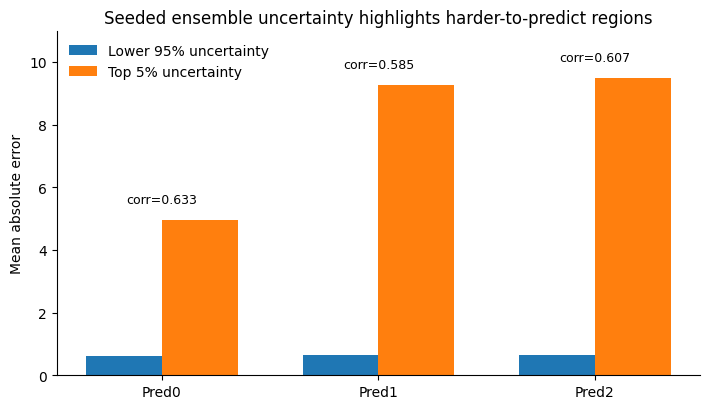

In [42]:
# ---------------------------------------------------------
# Compute Fig. 2 From ensemble_mean/std and GT
# ---------------------------------------------------------

rows = []

for pred_idx, gt_idx in enumerate(gt_match):
    # Prediction uncertainty and actual absolute error
    mu = ensemble_mean[pred_idx]
    sigma = ensemble_std[pred_idx]
    target = gt[gt_idx]

    error = np.abs(mu - target)

    # Pixel-wise uncertainty-error correlation
    corr = np.corrcoef(sigma.ravel(), error.ravel())[0, 1]

    # Top 5% most uncertain pixels
    threshold = np.quantile(sigma, 0.95)
    top_mask = sigma >= threshold
    lower_mask = sigma < threshold

    top_5_mae = float(error[top_mask].mean())
    lower_95_mae = float(error[lower_mask].mean())
    high_low_ratio = top_5_mae / lower_95_mae

    rows.append({
        "Horizon": f"Pred{pred_idx}",
        "Matched GT": f"GT{gt_idx}",
        "Corr": corr,
        "Lower 95% MAE": lower_95_mae,
        "Top 5% MAE": top_5_mae,
        "High/low error ratio": high_low_ratio,
    })

uncertainty_df = pd.DataFrame(rows)
display(uncertainty_df.round(4))

# Save the table
csv_path = os.path.join(SAVE_DIR, "ensemble_uncertainty_quality.csv")
uncertainty_df.to_csv(csv_path, index=False)
print("Saved uncertainty table:", csv_path)

# ---------------------------------------------------------
# Plot Fig. 2
# ---------------------------------------------------------
horizons = uncertainty_df["Horizon"].tolist()
x = np.arange(len(horizons))
width = 0.35

lower_95_mae = uncertainty_df["Lower 95% MAE"].to_numpy()
top_5_mae = uncertainty_df["Top 5% MAE"].to_numpy()
corr_values = uncertainty_df["Corr"].to_numpy()

fig, ax = plt.subplots(figsize=(7.2, 4.2))

ax.bar(
    x - width / 2,
    lower_95_mae,
    width,
    label="Lower 95% uncertainty"
)

ax.bar(
    x + width / 2,
    top_5_mae,
    width,
    label="Top 5% uncertainty"
)

ax.set_title("Seeded ensemble uncertainty highlights harder-to-predict regions")
ax.set_ylabel("Mean absolute error")
ax.set_xticks(x)
ax.set_xticklabels(horizons)
ax.legend(frameon=False)

# Correlation labels above each horizon
for i, corr in enumerate(corr_values):
    y_pos = max(lower_95_mae[i], top_5_mae[i]) + 0.45
    ax.text(
        x[i],
        y_pos,
        f"corr={corr:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_ylim(0, max(top_5_mae) + 1.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

png_path = os.path.join(SAVE_DIR, "fig2_ensemble_uncertainty.png")
pdf_path = os.path.join(SAVE_DIR, "fig2_ensemble_uncertainty.pdf")

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")

print("Saved figure:")
print(png_path)
print(pdf_path)

plt.show()